In [212]:
import math
import time
from typing import List
from pathlib import Path
import os
import sys
from math import pi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import sobel, gaussian_filter
from scipy.interpolate import UnivariateSpline
from scipy.signal import find_peaks
from scipy.optimize import curve_fit


from chars import greek, phys


In [213]:
cwd = Path(os.getcwd())

results_dir = cwd / "WS2_Grating_Eamonn" / "Results" / 'WS₂, SiO₂, Si' / 't=18.0nm Λ=500nm FF=0.84 N=75' / 'data'
# results_dir = cwd / "WS2_Grating_Eamonn" / "Results" / 'WS₂, SiO₂, Si 4' / 't=60.0nm Λ=350nm FF=0.55 N=75' / 'data'

files = sorted(os.listdir(results_dir))
file_R = results_dir / files[4]
file_R_sub = results_dir / files[5]
print(file_R)


C:\Users\whamp\PycharmProjects\research_project\WS2_Grating_Eamonn\Results\WS₂, SiO₂, Si\t=18.0nm Λ=500nm FF=0.84 N=75\data\WS₂, SiO₂, Si - t=18.0nm Λ=500nm FF=0.84_R_sub.csv


In [214]:
R = pd.read_csv(file_R, index_col=0)
Rsub = pd.read_csv(file_R_sub, index_col=0)

signalR = (R - Rsub) / Rsub
signalR = (signalR - np.min(signalR)) / (np.max(signalR) - np.min(signalR))

signalR.describe()

,-5.000000000000000000e+00,-4.864864864864864913e+00,-4.729729729729729826e+00,-4.594594594594594739e+00,-4.459459459459459651e+00,-4.324324324324324564e+00,-4.189189189189189477e+00,-4.054054054054054390e+00,-3.918918918918918859e+00,-3.783783783783783772e+00,...,3.783783783783784216e+00,3.918918918918919303e+00,4.054054054054054390e+00,4.189189189189189477e+00,4.324324324324324564e+00,4.459459459459459651e+00,4.594594594594594739e+00,4.729729729729729826e+00,4.864864864864864913e+00,5.000000000000000000e+00
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,...,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,0.327463,0.309657,0.293935,0.279307,0.264159,0.250787,0.240967,0.232193,0.221710,0.214354,...,0.214354,0.221710,0.232193,0.240967,0.250787,0.264159,0.279307,0.293935,0.309657,0.327463
std,0.158482,0.156259,0.154541,0.153006,0.150349,0.148387,0.146941,0.144541,0.140126,0.139107,...,0.139107,0.140126,0.144541,0.146941,0.148387,0.150349,0.153006,0.154541,0.156259,0.158482
min,0.099518,0.093637,0.088546,0.083038,0.078181,0.073953,0.069405,0.065353,0.061655,0.057822,...,0.057822,0.061655,0.065353,0.069405,0.073953,0.078181,0.083038,0.088546,0.093637,0.099518
25%,0.226243,0.211702,0.187672,0.178312,0.161298,0.145269,0.142943,0.144091,0.144486,0.132411,...,0.132411,0.144486,0.144091,0.142943,0.145269,0.161298,0.178312,0.187672,0.211702,0.226243
50%,0.325668,0.302878,0.289196,0.269220,0.250970,0.234261,0.218936,0.204859,0.193428,0.186420,...,0.186420,0.193428,0.204859,0.218936,0.234261,0.250970,0.269220,0.289196,0.302878,0.325668
75%,0.377170,0.352234,0.330289,0.309683,0.290878,0.273597,0.258003,0.243282,0.229602,0.216839,...,0.216839,0.229602,0.243282,0.258003,0.273597,0.290878,0.309683,0.330289,0.352234,0.377170
max,1.000000,0.977863,0.956082,0.934698,0.913755,0.893296,0.873370,0.854029,0.835334,0.817351,...,0.817351,0.835334,0.854029,0.873370,0.893296,0.913755,0.934698,0.956082,0.977863,1.000000


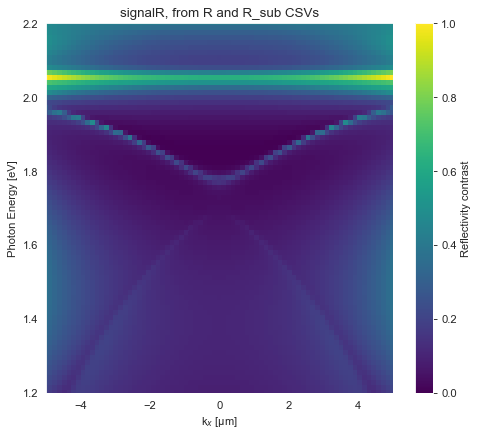

In [215]:
N=75
ev_wav_factor = 1.24
lbda_min = 2.2  # y limits in micrometers
lbda_max = 1.2
lbda = np.linspace(lbda_min, lbda_max, N)  # Generate wavelengths in micrometers

N_k=N
# k_scan=np.linspace(-6.7,6.7,N_k) #mu-1
kmax=5
k_scan=np.linspace(-kmax,kmax,N_k) #mu-1
ky=0.000
title_name = 'signalR, from R and R_sub CSVs'

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,lbda,signalR,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',
        xlim=(-kmax,kmax),ylim=(lbda_max, lbda_min), 
        ylabel='Photon Energy [eV]',
        title=title_name)
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()


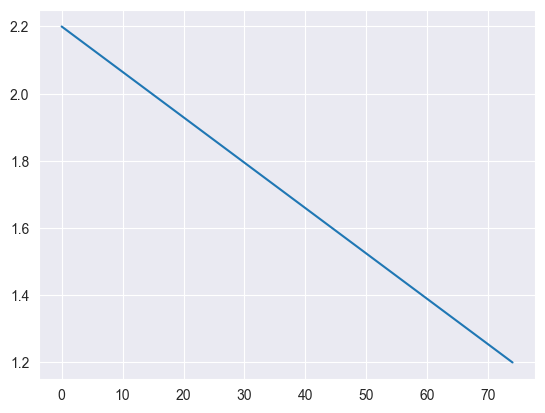

In [216]:
plt.plot(lbda)
plt.show()

(75, 75)


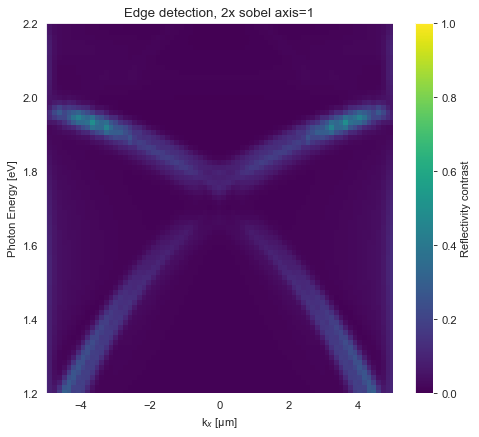

<Figure size 640x480 with 0 Axes>

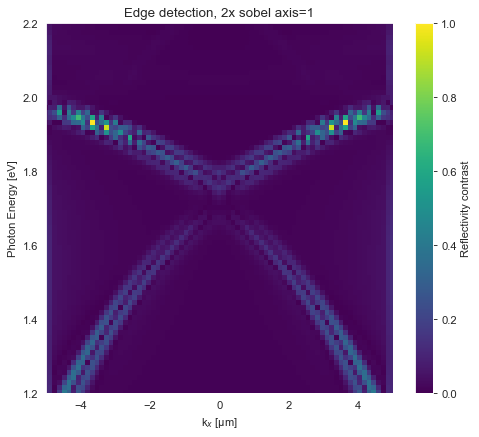

In [217]:
cwd=Path(os.getcwd())
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)


data_array = np.asarray(signalR)
sobel_x = sobel(data_array, axis=0)  # Sobel in the x-direction
sobel_y = sobel(data_array, axis=1)  # Sobel in the y-direction

sobel_y = sobel(sobel_y, axis=1)  # Sobel in the y-direction

# Calculate the gradient magnitude (combined Sobel in x and y)
sobel_magnitude = np.hypot(sobel_x, sobel_y)

edge_magnitude = np.abs(sobel_y)

# Normalize edge magnitude for better visualization
edge_magnitude_normalized = edge_magnitude / np.max(edge_magnitude)

# Apply Gaussian blur to smooth the edges (adjust sigma as needed for desired blur amount)
sigma = 0.8
edge_magnitude_blurred = gaussian_filter(edge_magnitude_normalized, sigma=sigma)


print(edge_magnitude.shape)

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,lbda,edge_magnitude_blurred,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(lbda_max, lbda_min), ylabel='Photon Energy [eV]',title='Edge detection, 2x sobel axis=1')
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()
plt.savefig(testpath / 'edgedetect_gaussian.png', dpi=150)
plt.show()
plt.clf()

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,lbda,edge_magnitude_normalized,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(lbda_max, lbda_min), ylabel='Photon Energy [eV]',title='Edge detection, 2x sobel axis=1')
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()
plt.savefig(testpath / 'edgedetect_normal.png', dpi=150)




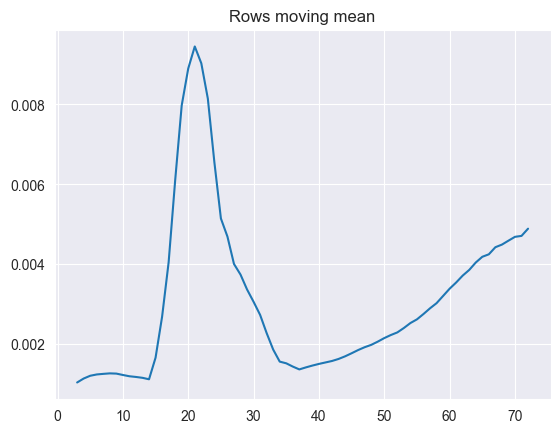

In [218]:

# find the coords of above and below the top mode, identify the gap
line_y_max = [np.max(row)*np.mean(row)/np.sum(row) for row in edge_magnitude_normalized]

# apply 3 point moving average to line_y_max

pd_line_y_max = pd.Series(line_y_max)
# pd_line_y_max.plot(title='Max val of rows')

# Apply a 3-point moving average to smooth the data
pd_line_y_max_smoothed = pd_line_y_max.rolling(window=6, center=True).mean()
pd_line_y_max_smoothed.plot(title='Rows moving mean')

plt.savefig(testpath / 'lineprofile.png', dpi=150)


Peak at 21 - before=14, after=37, diff 0.008074782228564044
Found peak at idx 21


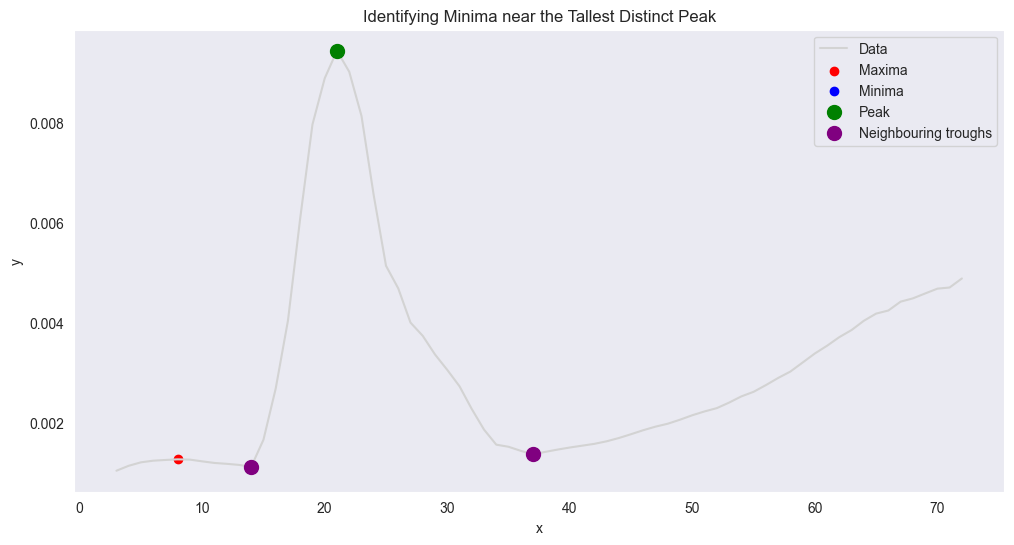

In [219]:

# Use the Series index as x values
y = pd_line_y_max_smoothed
x = pd_line_y_max_smoothed.index

peaks, _ = find_peaks(y)
troughs, _ = find_peaks(-y)  # Invert y to find minima

# peaks_df = pd.Series(peaks)
# troughs_df = pd.Series(troughs)
# pt_df = pd.DataFrame({'peaks':peaks_df, 'troughs':troughs_df})
# print(pt_df)

minima_indices = troughs
min_peak_trough_diff = 0.6

max_peak = None # [loc, comparable diff]
min_troughs = None # [loc1, loc2]

for _,peak in enumerate(peaks):
    before_trough = troughs[troughs < peak].max() if (troughs < peak).any() else None
    after_trough = troughs[troughs > peak].min() if (troughs > peak).any() else None
    
    if None in [before_trough, after_trough]:
        continue
    before_trough = int(before_trough)
    after_trough = int(after_trough)
    
    diff1, diff2 = y[peak] - y[before_trough], y[peak] - y[after_trough]
    diff_min = np.min([diff1, diff2]) # find min proximity in y to trough
    
    if max_peak == None or max_peak[1] < diff_min:
        max_peak = [peak,diff_min]
        min_troughs = [before_trough, after_trough]
    
    print(f"Peak at {peak} - before={before_trough}, after={after_trough}, diff {diff_min}")

print(f"Found peak at idx {max_peak[0]}")
    


# Step 5: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Data', color='lightgray')
plt.scatter(x[peaks], y[peaks], color='red', label='Maxima')
plt.scatter(x[minima_indices], y[minima_indices], color='blue', label='Minima', zorder=5)
plt.scatter(x[max_peak[0]], y[max_peak[0]], color='green', label='Peak', s=100, zorder=10)
plt.scatter([x[min_troughs[0]], x[min_troughs[1]]], [y[min_troughs[0]], y[min_troughs[1]]], color='purple', label='Neighbouring troughs', s=100, zorder=10)
plt.title('Identifying Minima near the Tallest Distinct Peak')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()

plt.savefig(testpath / 'peaks.png', dpi=150)
plt.show()

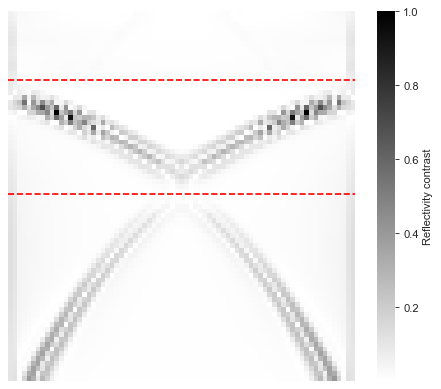

In [220]:
# Create a new figure for the heatmap
plt.figure(figsize=(7, 6), dpi=80)

# Use seaborn to create a heatmap
sns.heatmap(edge_magnitude_normalized, cmap='binary', cbar_kws={'label': 'Reflectivity contrast'}, 
            xticklabels=False, yticklabels=False)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='r', linestyle='--')
plt.axhline(y=min_troughs[1], color='r', linestyle='--')

plt.minorticks_on()

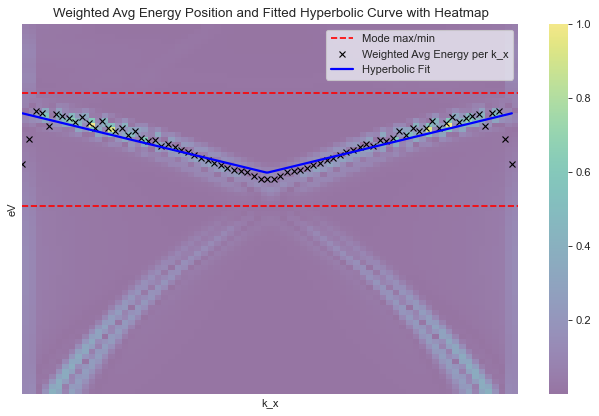

Fitted parameters:
h = 30.1866, a = -0.3087, b = 0.0000, k = 37.0000, v = 0.0340


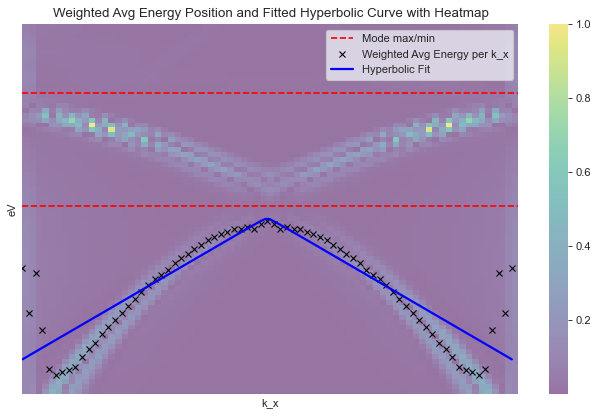

Fitted parameters:
h = 39.1502, a = 3.4466, b = -0.1119, k = 37.0000, v = 0.0340


In [221]:
v1 = 0.034  # eV.um
U = 0.090  # eV
E0 = 1.47  # eV

def hyperbolic_model(x, h, a, b, k, v):
    return h + a * np.sqrt(b**2 + (v*(x - k))**2)

# Directory setup
cwd = Path(os.getcwd())
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)

# Create a heatmap (visualization)
plt.figure(figsize=(10, 6), dpi=80)
sns.heatmap(edge_magnitude_normalized, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='r', linestyle='--', label='Mode max/min')
plt.axhline(y=min_troughs[1], color='r', linestyle='--')

# Extract the region of interest between the minimum troughs
y_min, y_max = min_troughs[0], min_troughs[1]
data_region = edge_magnitude_normalized[y_min:y_max, :]  # Get data between min_troughs

x_indices = np.arange(data_region.shape[1])

# Calculate weighted average energy positions for the top 25 quantile values
y_positions = []
for x in x_indices:
    column = data_region[:, x]
    y_indices = np.arange(len(column))  # y-axis indices (energies)

    # Find the threshold for the top 25% quantile
    quantile_threshold = np.percentile(column, 80)

    # Filter values to only those above the 75th percentile
    filtered_indices = np.where(column >= quantile_threshold)[0]
    filtered_column = column[filtered_indices]
    filtered_y_indices = y_indices[filtered_indices]  # Corresponding y indices

    # Calculate the weighted average for the filtered values
    if np.sum(filtered_column) > 0:  # Avoid division by zero if the filtered column is empty
        weighted_avg = np.sum(filtered_column * filtered_y_indices) / np.sum(filtered_column)
        y_positions.append(weighted_avg + y_min)  # Adjust by y_min to reflect the original position
    else:
        # If no values exceed the threshold, use a fallback value
        y_positions.append((y_max + y_min) / 2)

# Convert to arrays for curve fitting
x_data = np.array(x_indices)
y_data = np.array(y_positions)

# Perform curve fitting (using hyperbolic fit)
initial_guess = [E0, 1, U, np.mean(x_data), v1]
popt, pcov = curve_fit(hyperbolic_model, x_data, y_data, p0=initial_guess)

# Generate smooth x-values for plotting the fitted curve
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)
y_fit = hyperbolic_model(x_smooth, *popt)

# Overlay the weighted average data and the fitted hyperbolic curve on the heatmap
plt.plot(x_data, y_data, 'x', color='black', markersize=6, label='Weighted Avg Energy per k_x')
plt.plot(x_smooth, y_fit, color='blue', linewidth=2, label='Hyperbolic Fit')

# Configure the plot
plt.xlabel('k_x')
plt.ylabel('eV')
plt.legend()
plt.xticks()
plt.minorticks_on()
plt.title('Weighted Avg Energy Position and Fitted Hyperbolic Curve with Heatmap')
plt.savefig(testpath / 'hyperbolic_fit_with_weighted_avg_and_heatmap.png', dpi=150)
plt.show()

# Print fitted parameters for reference
h, a, b, k, v = popt
print(f"Fitted parameters:\nh = {h:.4f}, a = {a:.4f}, b = {b:.4f}, k = {k:.4f}, v = {v1:.4f}")









# Create a heatmap (visualization)
plt.figure(figsize=(10, 6), dpi=80)
sns.heatmap(edge_magnitude_normalized, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='r', linestyle='--', label='Mode max/min')
plt.axhline(y=min_troughs[1], color='r', linestyle='--')

# Extract the region of interest between the minimum troughs
y_min, y_max = min_troughs[1], None
data_region_2 = edge_magnitude_normalized[y_min:y_max, :]  # Get data between min_troughs

x_indices = np.arange(data_region_2.shape[1])

# Calculate weighted average energy positions for the top 25 quantile values
y_positions = []
for x in x_indices:
    column = data_region_2[:, x]
    y_indices = np.arange(len(column))  # y-axis indices (energies)

    # Find the threshold for the top 25% quantile
    quantile_threshold = np.percentile(column, 80)

    # Filter values to only those above the 75th percentile
    filtered_indices = np.where(column >= quantile_threshold)[0]
    filtered_column = column[filtered_indices]
    filtered_y_indices = y_indices[filtered_indices]  # Corresponding y indices

    # Calculate the weighted average for the filtered values
    if np.sum(filtered_column) > 0:  # Avoid division by zero if the filtered column is empty
        weighted_avg = np.sum(filtered_column * filtered_y_indices) / np.sum(filtered_column)
        y_positions.append(weighted_avg + y_min)  # Adjust by y_min to reflect the original position
    else:
        # If no values exceed the threshold, use a fallback value
        y_positions.append((y_max + y_min) / 2)

# Convert to arrays for curve fitting
x_data = np.array(x_indices)
y_data = np.array(y_positions)

# Perform curve fitting (using hyperbolic fit)
initial_guess = [E0, 1, U, np.mean(x_data), v1]
popt, pcov = curve_fit(hyperbolic_model, x_data, y_data, p0=initial_guess)

# Generate smooth x-values for plotting the fitted curve
x_smooth = np.linspace(0, data_region_2.shape[1] - 1, 300)
y_fit = hyperbolic_model(x_smooth, *popt)

# Overlay the weighted average data and the fitted hyperbolic curve on the heatmap
plt.plot(x_data, y_data, 'x', color='black', markersize=6, label='Weighted Avg Energy per k_x')
plt.plot(x_smooth, y_fit, color='blue', linewidth=2, label='Hyperbolic Fit')

# Configure the plot
plt.xlabel('k_x')
plt.ylabel('eV')
plt.legend()
plt.xticks()
plt.minorticks_on()
plt.title('Weighted Avg Energy Position and Fitted Hyperbolic Curve with Heatmap')
plt.savefig(testpath / 'hyperbolic_fit_with_weighted_avg_and_heatmap.png', dpi=150)
plt.show()

# Print fitted parameters for reference
h, a, b, k, v = popt
print(f"Fitted parameters:\nh = {h:.4f}, a = {a:.4f}, b = {b:.4f}, k = {k:.4f}, v = {v1:.4f}")




(75,) (75,)
PCOV cleaned: [[ 9.34358147e+06 -1.16377929e+04 -7.72976802e+11  1.99615308e+06
  -9.80461682e+08  1.56951787e+07 -3.58374394e+07 -3.03989164e+08]
 [-1.16377929e+04  1.44953501e+01  9.62774432e+08 -2.48530167e+03
   1.22072145e+06 -1.95501262e+04  4.46383804e+04  3.78617927e+05]
 [-7.72976802e+11  9.62774432e+08  6.39470375e+16 -1.64213104e+11
   8.06576651e+13 -1.29859330e+12  2.96429863e+12  2.51467531e+13]
 [ 1.99615308e+06 -2.48530167e+03 -1.64213104e+11  1.15761427e+08
  -5.68499705e+10 -7.78086502e+06 -8.30616874e+07 -1.82155662e+08]
 [-9.80461682e+08  1.22072145e+06  8.06576651e+13 -5.68499705e+10
   2.79187915e+13  3.82080539e+09  4.07919964e+10  8.94602498e+10]
 [ 1.56951787e+07 -1.95501262e+04 -1.29859330e+12 -7.78086502e+06
   3.82080539e+09  3.84084166e+07 -7.67648312e+07 -3.83851546e+08]
 [-3.58374394e+07  4.46383804e+04  2.96429863e+12 -8.30616874e+07
   4.07919964e+10 -7.67648312e+07  2.38592094e+08  9.91576789e+08]
 [-3.03989164e+08  3.78617927e+05  2.514675

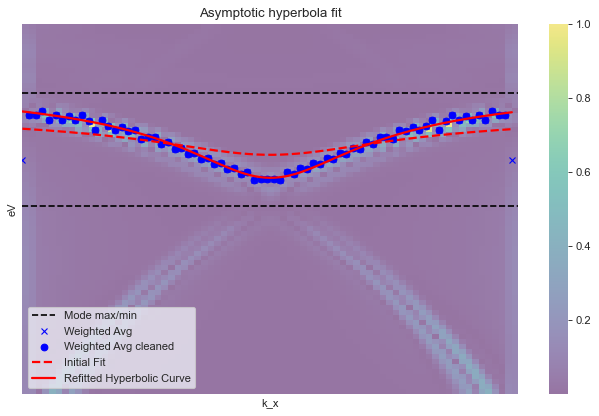

Fitted parameters (initial hyperbolic):
a = 0.0797, b = 37.5000, L = 6999.9990, M = 0.6000, F = 500.0000, B = 0.3863, sign = -1.0000, V = 4.9998
Fitted parameters (cleaned hyperbolic):
a = 0.0964, b = 24.7851, L = 7973.0114, M = 0.5796, F = 284.6336, B = 0.4598, sign = -1.0000, V = 4.8405


RMSE: 1.6911940274892192, R^2: 0.8485039305865962


In [222]:

# Define the hyperbolic asymptotic model for curve fitting
def hyperbola_asymptotic(x, a, b, L, M, F, B, sign, V):
    """
    Hyperbolic asymptotic fit model
    :param x: x
    :param a: shift y
    :param b: shift x (redundant, =N/2)
    :param L: multiply y
    :param M: multiply x
    :param F: pointyness
    :param B: asymptote in y
    :param sign: u or n shape
    :return: g(x) func result
    """
    xbM = ((x - 37.5) ** 2) / M
    f_x = sign*np.sqrt(np.abs( (F + xbM) ))
    g_x = a + ( f_x / (V*( 1 + (np.abs(f_x) / B) )) )
    return g_x * L

# Directory setup
cwd = Path().cwd()
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)

# Create a heatmap (visualization)
plt.figure(figsize=(10, 6), dpi=80)
sns.heatmap(edge_magnitude_normalized, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='black', linestyle='--', label='Mode max/min')
plt.axhline(y=min_troughs[1], color='black', linestyle='--')

# Extract the region of interest between the minimum troughs
y_min, y_max = min_troughs[0], min_troughs[1]
data_region = edge_magnitude_normalized[y_min:y_max, :]
x_indices = np.arange(data_region.shape[1])

# Calculate weighted average energy positions for the top 25 quantile values
y_positions = []
for x in x_indices:
    column = data_region[:, x]
    y_indices = np.arange(len(column))

    quantile_threshold = np.percentile(column, 95)
    filtered_indices = np.where(column >= quantile_threshold)[0]
    filtered_column = column[filtered_indices]
    filtered_y_indices = y_indices[filtered_indices]

    if np.sum(filtered_column) > 0:
        weighted_avg = np.sum(filtered_column * filtered_y_indices) / np.sum(filtered_column)
        y_positions.append(weighted_avg + y_min)
    else:
        y_positions.append((y_max + y_min) / 2)

x_data = np.array(x_indices)
y_data = np.array(y_positions)

print(np.shape(y_data), np.shape(x_data))

N = 75

initial_guess = \
    [0.3, N / 2, 7000, 0.6, 500, 0.3, -1, 5] # a = 0.0797, b = 37.5000, L = 6999.9990, M = 0.6000, F = 500.0000, B = 0.3863, sign = -1.0000, V = 4.9998
bounds = \
    ([-50, 0, 100, 0.5, 1, 0, -1, 1], 
     [50, N, 10000, 10, 10000, 100, 1, 20])

# Perform hyperbolic curve fitting
popt, pcov = curve_fit(hyperbola_asymptotic, x_data, y_data, 
                       p0=initial_guess, bounds=bounds, maxfev=10000)

# Generate smooth x-values for plotting the fitted hyperbolic curve
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)
y_fit = hyperbola_asymptotic(x_smooth, *popt)

# Calculate residuals and identify outliers
residuals = y_data - hyperbola_asymptotic(x_data, *popt)
threshold = 2 * np.std(residuals)
outlier_indices = np.abs(residuals) > threshold
x_data_cleaned = x_data[~outlier_indices]
y_data_cleaned = y_data[~outlier_indices]


initial_guess_2 = popt

# Refit the hyperbolic model to the cleaned data
popt_cleaned, pcov_cleaned = curve_fit(hyperbola_asymptotic, x_data_cleaned, y_data_cleaned, p0=initial_guess_2, bounds=bounds, maxfev=10000)
y_fit_cleaned = hyperbola_asymptotic(x_smooth, *popt_cleaned)
print(f"PCOV cleaned: {pcov_cleaned}")

# Overlay the data and the fitted hyperbolic curve on the heatmap
plt.plot(x_data, y_data, 'bx', markersize=6, label='Weighted Avg')
plt.plot(x_data_cleaned, y_data_cleaned, 'bo', markersize=6, label='Weighted Avg cleaned')
plt.plot(x_smooth, y_fit, 'r--', linewidth=2, label='Initial Fit')
plt.plot(x_smooth, y_fit_cleaned, 'r-', linewidth=2, label='Refitted Hyperbolic Curve')



# Configure the plot
plt.xlabel('k_x')
plt.ylabel('eV')
plt.legend()
plt.minorticks_on()
plt.title('Asymptotic hyperbola fit')
plt.savefig(testpath / 'hyperbolic_fit_with_weighted_avg_and_heatmap.png', dpi=150)
plt.show()

# Print fitted parameters for reference
a, b, L, M, F, B, sign, V = popt
print(f"Fitted parameters (initial hyperbolic):\na = {a:.4f}, b = {b:.4f}, L = {L:.4f}, M = {M:.4f}, F = {F:.4f}, B = {B:.4f}, sign = {sign:.4f}, V = {V:.4f}")

a_cleaned, b_cleaned, L_cleaned, M_cleaned, F_cleaned, B_cleaned, sign_cleaned, V_cleaned = popt_cleaned
print(f"Fitted parameters (cleaned hyperbolic):\na = {a_cleaned:.4f}, b = {b_cleaned:.4f}, L = {L_cleaned:.4f}, M = {M_cleaned:.4f}, F = {F_cleaned:.4f}, B = {B_cleaned:.4f}, sign = {sign:.4f}, V = {V_cleaned:.4f}")


residuals = y_data - hyperbola_asymptotic(x_data, *popt_cleaned)
rmse = np.sqrt(np.mean(residuals**2))
ss_total = np.sum((y_data - np.mean(y_data))**2)
ss_residual = np.sum(residuals**2)
r2 = 1 - (ss_residual / ss_total)
print(f"\n\nRMSE: {rmse}, R^2: {r2}")




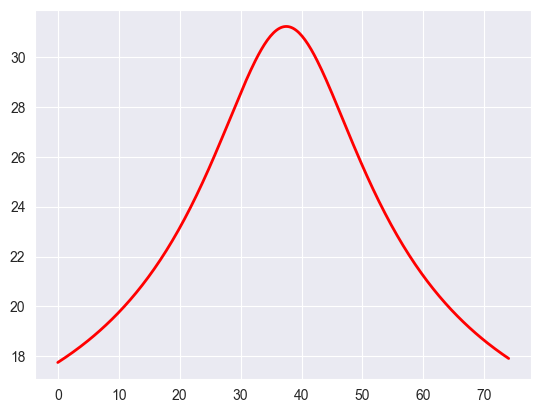

In [223]:
plt.plot(x_smooth, y_fit_cleaned, 'r-', linewidth=2, label='Refitted Hyperbolic Curve')

(75,) (75,)
Fitted parameter variance/s: 
a       2.138080e+07
b       3.790107e+01
L       8.319392e+15
M       8.498202e+07
F       1.372851e+14
B       9.815778e+07
sign    4.092486e+07
V       3.262249e+09
Name: pcov, dtype: float64


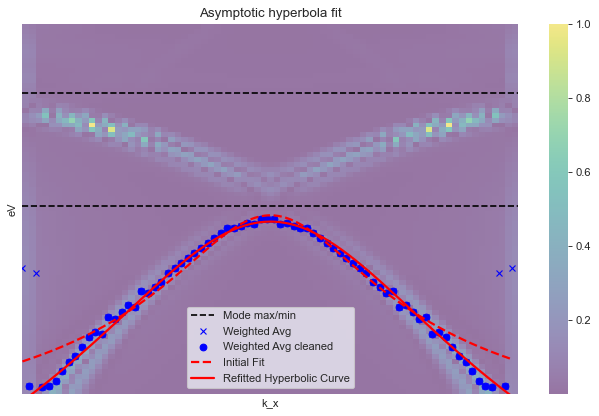

Fitted parameters (initial hyperbolic):
a = -0.1648, b = 18.4234, L = 7011.2331, M = 0.5515, F = 462.2765, B = 0.8920, sign = 1.0000, V = 5.0284
Fitted parameters (cleaned hyperbolic):
a_2 = -0.3077, b_2 = 0.3750, L_2 = 6064.2243, M_2 = 0.8264, F_2 = 1050.3883, B_2 = 1.6729, sign_2 = 1.0000, V_2 = 5.0611
              pcov  fitted value         stdev
a     2.138080e+07     -0.164791  4.623938e+03
b     3.790107e+01     18.423438  6.156384e+00
L     8.319392e+15   7011.233079  9.121070e+07
M     8.498202e+07      0.551493  9.218569e+03
F     1.372851e+14    462.276504  1.171687e+07
B     9.815778e+07      0.892010  9.907461e+03
sign  4.092486e+07      0.999972  6.397254e+03
V     3.262249e+09      5.028364  5.711610e+04


RMSE: 5.865491285556124, R^2: 0.7075382728240056


In [224]:

# Define the hyperbolic asymptotic model for curve fitting
def hyperbola_asymptotic(x, a, b, L, M, F, B, sign, V):
    """
    Hyperbolic asymptotic fit model
    :param x: x
    :param a: shift y
    :param b: shift x (redundant, =N/2)
    :param L: multiply y
    :param M: multiply x
    :param F: pointyness
    :param B: asymptote in y
    :param sign: u or n shape
    :return: g(x) func result
    """
    xbM = ((x - 37.5) ** 2) / M
    f_x = sign*np.sqrt(np.abs( (F + xbM) ))
    g_x = a + ( f_x / (V*( 1 + (np.abs(f_x) / B) )) )
    return g_x * L

# Directory setup
cwd = Path().cwd()
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)

# Create a heatmap (visualization)
plt.figure(figsize=(10, 6), dpi=80)
sns.heatmap(edge_magnitude_normalized, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='black', linestyle='--', label='Mode max/min')
plt.axhline(y=min_troughs[1], color='black', linestyle='--')

# Extract the region of interest between the minimum troughs
y_min, y_max = min_troughs[1], None
data_region = edge_magnitude_normalized[y_min:y_max, :]
x_indices = np.arange(data_region.shape[1])

# Calculate weighted average energy positions for the top 25 quantile values
y_positions = []
for x in x_indices:
    column = data_region[:, x]
    y_indices = np.arange(len(column))

    quantile_threshold = np.percentile(column, 95)
    filtered_indices = np.where(column >= quantile_threshold)[0]
    filtered_column = column[filtered_indices]
    filtered_y_indices = y_indices[filtered_indices]

    if np.sum(filtered_column) > 0:
        weighted_avg = np.sum(filtered_column * filtered_y_indices) / np.sum(filtered_column)
        y_positions.append(weighted_avg + y_min)
    else:
        y_positions.append((y_max + y_min) / 2)

x_data = np.array(x_indices)
y_data = np.array(y_positions)

print(np.shape(y_data), np.shape(x_data))

N = 75

initial_guess = \
    [0.3, N / 2, 7000, 0.6, 500, 0.3, 1, 5] # a = 0.0797, b = 37.5000, L = 6999.9990, M = 0.6000, F = 500.0000, B = 0.3863, sign = -1.0000, V = 4.9998
bounds = \
    ([-50, 0, 100, 0.5, 1, 0, -1, 1], 
     [50, N, 10000, 10, 10000, 100, 1, 20])

# Perform hyperbolic curve fitting
popt, pcov = curve_fit(hyperbola_asymptotic, x_data, y_data, 
                       p0=initial_guess, bounds=bounds, maxfev=10000)

# Generate smooth x-values for plotting the fitted hyperbolic curve
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)
y_fit_2 = hyperbola_asymptotic(x_smooth, *popt)

# Calculate residuals and identify outliers
residuals = y_data - hyperbola_asymptotic(x_data, *popt)
threshold = 2 * np.std(residuals)
outlier_indices = np.abs(residuals) > threshold
x_data_cleaned = x_data[~outlier_indices]
y_data_cleaned = y_data[~outlier_indices]

initial_guess_2 = popt

# Refit the hyperbolic model to the cleaned data
popt_cleaned, pcov_cleaned2 = curve_fit(hyperbola_asymptotic, x_data_cleaned, y_data_cleaned, p0=initial_guess_2, bounds=bounds, maxfev=10000)
y_fit_cleaned_2 = hyperbola_asymptotic(x_smooth, *popt_cleaned)

series_pcov = pd.Series(np.diag(pcov_cleaned2), index=['a', 'b', 'L', 'M', 'F', 'B', 'sign', 'V'], name='pcov')
print(f"Fitted parameter variance/s: \n{series_pcov}")

# Overlay the data and the fitted hyperbolic curve on the heatmap
plt.plot(x_data, y_data, 'bx', markersize=6, label='Weighted Avg')
plt.plot(x_data_cleaned, y_data_cleaned, 'bo', markersize=6, label='Weighted Avg cleaned')
plt.plot(x_smooth, y_fit_2, 'r--', linewidth=2, label='Initial Fit')
plt.plot(x_smooth, y_fit_cleaned_2, 'r-', linewidth=2, label='Refitted Hyperbolic Curve')



# Configure the plot
plt.xlabel('k_x')
plt.ylabel('eV')
plt.legend()
plt.minorticks_on()
plt.title('Asymptotic hyperbola fit')
plt.savefig(testpath / 'hyperbolic_fit_with_weighted_avg_and_heatmap.png', dpi=150)
plt.show()

# Print fitted parameters for reference
a, b, L, M, F, B, sign, V = popt
print(f"Fitted parameters (initial hyperbolic):\na = {a:.4f}, b = {b:.4f}, L = {L:.4f}, M = {M:.4f}, F = {F:.4f}, B = {B:.4f}, sign = {sign:.4f}, V = {V:.4f}")
series_values = pd.Series(popt, index=['a', 'b', 'L', 'M', 'F', 'B', 'sign', 'V'], name='fitted value')
#print(series_values)

a_cleaned_2, b_cleaned_2, L_cleaned_2, M_cleaned_2, F_cleaned_2, B_cleaned_2, sign_cleaned_2, V_cleaned_2 = popt_cleaned
print(f"Fitted parameters (cleaned hyperbolic):\n"
      f"a_2 = {a_cleaned_2:.4f}, b_2 = {b_cleaned_2:.4f}, L_2 = {L_cleaned_2:.4f}, M_2 = {M_cleaned_2:.4f}, "
      f"F_2 = {F_cleaned_2:.4f}, B_2 = {B_cleaned_2:.4f}, sign_2 = {sign_cleaned_2:.4f}, V_2 = {V_cleaned_2:.4f}")

df_errors = pd.concat([series_pcov, series_values], axis=1)
df_errors['stdev'] = df_errors['pcov'].apply(np.sqrt)
print(df_errors)

residuals_2 = y_data - hyperbola_asymptotic(x_data, *popt_cleaned)
rmse_2 = np.sqrt(np.mean(residuals_2**2))
ss_total_2 = np.sum((y_data - np.mean(y_data))**2)
ss_residual_2 = np.sum(residuals_2**2)
r2_2 = 1 - (ss_residual_2 / ss_total_2)
print(f"\n\nRMSE: {rmse_2}, R^2: {r2_2}")



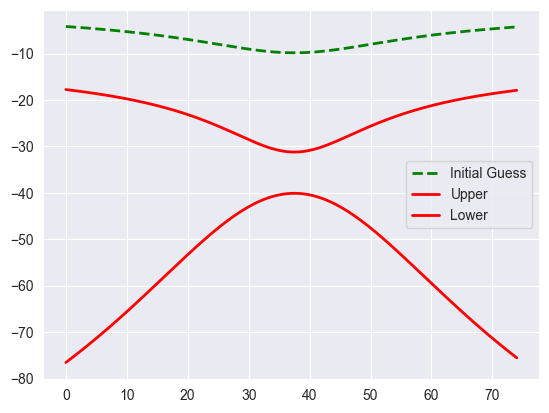

In [225]:
# a = 0.0797, b = 37.5000, L = 6999.9990, M = 0.6000, F = 500.0000, B = 0.3863, sign = -1.0000, V = 4.9998
initial_guess = [0.08, N/2, 7000, 0.6, 500, 0.4, -1, 5]

# Calculate the initial guess for the hyperbolic curve
y_initial_guess = hyperbola_asymptotic(x_smooth, *initial_guess)  # Calculate initial guess
plt.plot(x_smooth, -y_initial_guess, 'g--', linewidth=2, label='Initial Guess')  # Add this line
plt.plot(x_smooth, -y_fit_cleaned, 'r-', linewidth=2, label='Upper')
plt.plot(x_smooth, -y_fit_cleaned_2, 'r-', linewidth=2, label='Lower')
plt.legend()



In [226]:
# decide whether the fits are good

R2_threshold = 0.6

for _,R2 in enumerate([r2, r2_2]):
    print(R2)
    if R2 > R2_threshold:
        print("Within threshold")
    elif R2 < R2_threshold:
        print("Not within threshold")
    


0.8485039305865962
Within threshold
0.7075382728240056
Within threshold


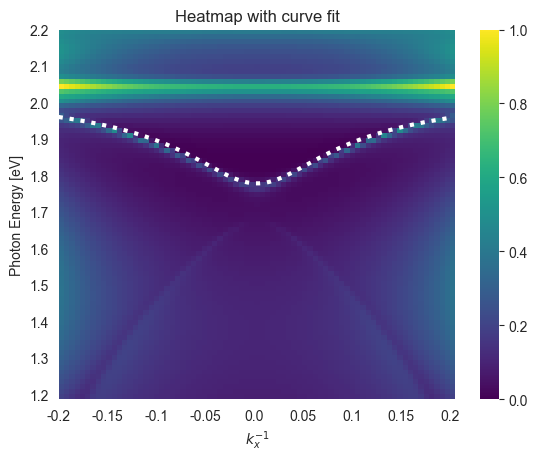

In [227]:

# Plot the heatmap
sns.heatmap(signalR, cmap='viridis', xticklabels=0, yticklabels=0, alpha=1)

# Add the fitted curve
plt.plot(x_smooth, y_fit_cleaned, 'w:', linewidth=3, label='Hyperbolic', alpha=1)

# Configure the x-axis and y-axis ticks with rounded labels
x_ticks = np.linspace(0, signalR.shape[1] - 1, num=9)
x_labels = np.round(np.linspace((-1/5), (1/5), num=9), 2)
plt.xticks(ticks=x_ticks, labels=x_labels)

y_ticks = np.linspace(0, signalR.shape[0] - 1, num=11)
y_labels = np.round(np.linspace(2.2, 1.2, num=11), 1)
plt.yticks(ticks=y_ticks, labels=y_labels)

# Configure labels, title, and save
plt.xlabel('$k_x^{-1}$')
plt.ylabel('Photon Energy [eV]')
plt.title('Heatmap with curve fit')
plt.savefig(testpath / 'heatmap_curvefit.png', dpi=150)

# Display the plot
plt.show()



0.021702374969907907


C:\Users\whamp\AppData\Local\Temp\ipykernel_11680\154124052.py:30: RuntimeWarning: invalid value encountered in sqrt
  numerator = B**2 * L * sign * np.sqrt(2 * x_val - N)


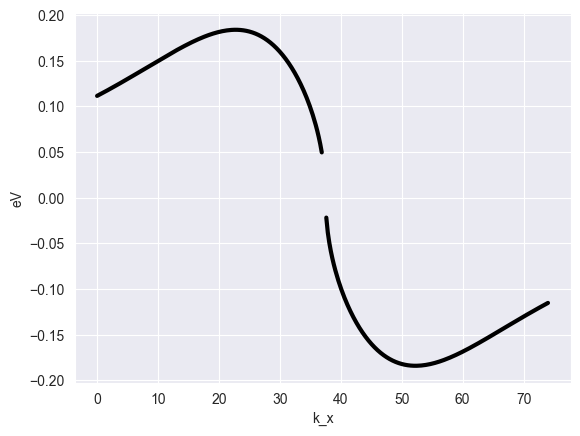

In [228]:
N=75

def hyperbola_asymptotic_derivative(x, a, b, L, M, F, B, sign, V):
    """
    Hyperbolic asymptotic derivative with split calculations based on index location.
    :param x: x values (assumes x is an array)
    :param a: shift y
    :param b: shift x (redundant, =N/2)
    :param L: multiply y
    :param M: multiply x
    :param F: pointyness
    :param B: asymptote in y
    :param sign: u or n shape
    :param V: scaling factor
    :return: Calculated derivative values for each x
    """
    # Calculate the halfway index of x_smooth
    half_length = len(x) // 2
    result = np.zeros_like(x)  # Preallocate result array
    
    # Define functions for before and after halfway
    def compute_before_half(x_val):
        numerator = B**2 * L * sign * np.sqrt(abs(2 * x_val - N))
        d1 = 2 * V * np.sqrt((x_val - (N / 2))**2 + F)
        d2 = sign * np.sqrt((x_val - (N / 2))**2 + F) + B
        denominator = d1 * d2**2
        return -numerator / denominator

    def compute_after_half(x_val):
        numerator = B**2 * L * sign * np.sqrt(2 * x_val - N)
        d1 = 2 * V * np.sqrt((x_val - (N / 2))**2 + F)
        d2 = sign * np.sqrt((x_val - (N / 2))**2 + F) + B
        denominator = d1 * d2**2
        return numerator / denominator
    
    # Apply calculations based on index location
    for i in range(len(x)):
        if i < half_length:
            result[i] = compute_before_half(x[i])
        else:
            result[i] = compute_after_half(x[i])

    return result


y_derivative = hyperbola_asymptotic_derivative(x_smooth, *popt_cleaned)

# sns.heatmap(signalR, cmap='viridis', xticklabels=0, yticklabels=0, alpha=1)

plt.plot(x_smooth, -y_derivative, 'k-', linewidth=3, label='Derivative', alpha=1)
# plt.plot(x_smooth, y_fit_cleaned, 'r-', linewidth=2, label='Hyperbolic')

ind = len(y_derivative)//2 + 2
print(y_derivative[ind])

# Configure the plot
plt.xlabel('k_x')
plt.ylabel('eV')

# plt.title('Heatmap with curve fit')
# plt.savefig(testpath / 'heatmap_curvefit.png', dpi=150)
plt.show()



Fitted parameters:
a = 0.0964, b = 24.7851, L = 7973.0114, M = 0.5796, F = 284.6336, B = 0.4598, sign = 1.0000, V = 4.8405
Fitted parameters 2:
a_2 = -0.3077, b_2 = 0.3750, L_2 = 6064.2243, M_2 = 0.8264, F_2 = 1050.3883, B_2 = 1.6729, sign_2 = 1.0000, V_2 = 5.0611


Upper mode (sign -1)
Vertex - -17.878
Asymptote - -18.146

Upper mode (sign 1)
Vertex - 1.665
Asymptote - 0.353 

DIFF = 19.543


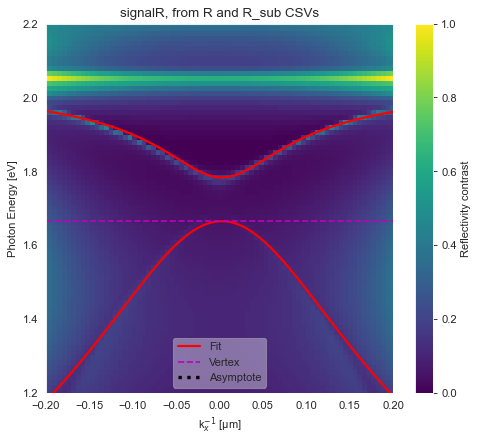

In [230]:
def fitted_to_graph(array: list | float, N: int = N) -> list | float:
    """
    Convert pixel coords/positions to eV given 1.2, 2.2 range, with N length square dimension array
    :param array: list or single number
    :return: new list or number
    """
    max_energy, min_energy = 2.2, 1.2
    min_pixel, max_pixel = 0, N
    # Correct scaling formula
    energy_values = max_energy - (array - min_pixel) * (max_energy - min_energy) / (max_pixel - min_pixel)
    return energy_values

k_scan_line = np.linspace(-1/kmax, 1/kmax, 300)
k_scan = np.linspace(-1/kmax, 1/kmax, N)

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,lbda,signalR,cmap='viridis',clim=(0,1))
m1 = r'{-1}'
axs.set(xlabel=f'k$_x^{m1}$ [{greek.mu}m]',xlim=(-1/kmax,1/kmax),ylim=(lbda_max, lbda_min), ylabel='Photon Energy [eV]',title=title_name)
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()


axs.plot(k_scan_line, fitted_to_graph(y_fit_cleaned), 'r-', linewidth=2, label='Fit')
axs.plot(k_scan_line, fitted_to_graph(y_fit_cleaned_2), 'r-', linewidth=2)

print(f"Fitted parameters:\na = {a_cleaned:.4f}, b = {b_cleaned:.4f}, L = {L_cleaned:.4f}, M = {M_cleaned:.4f}, F = {F_cleaned:.4f}, B = {B_cleaned:.4f}, sign = {sign:.4f}, V = {V_cleaned:.4f}")
print(f"Fitted parameters 2:\n"
      f"a_2 = {a_cleaned_2:.4f}, b_2 = {b_cleaned_2:.4f}, L_2 = {L_cleaned_2:.4f}, M_2 = {M_cleaned_2:.4f}, "
      f"F_2 = {F_cleaned_2:.4f}, B_2 = {B_cleaned_2:.4f}, sign_2 = {sign_cleaned_2:.4f}, V_2 = {V_cleaned_2:.4f}")


# def hyperbola_asymptotic(x, a, b, L, M, F, B, sign, V)

vertex = fitted_to_graph(hyperbola_asymptotic(N/2, a_cleaned, b_cleaned, L_cleaned, M_cleaned, F_cleaned, B_cleaned, sign, V_cleaned))
vertex_2 = fitted_to_graph(hyperbola_asymptotic(N/2, a_cleaned_2, b_cleaned_2, L_cleaned_2, M_cleaned_2, F_cleaned_2, B_cleaned_2, sign_cleaned_2, V_cleaned_2))

asym = fitted_to_graph(hyperbola_asymptotic(1e9, a_cleaned, b_cleaned, L_cleaned, M_cleaned, F_cleaned, B_cleaned, sign, V_cleaned))
asym_2 = fitted_to_graph(hyperbola_asymptotic(1e9, a_cleaned_2, b_cleaned_2, L_cleaned_2, M_cleaned_2, F_cleaned_2, B_cleaned_2, sign_cleaned_2, V_cleaned_2))

print(f"\n\nUpper mode (sign {sign_cleaned:.0f})\n"
      f"Vertex - {vertex:.3f}\nAsymptote - {asym:.3f}\n\n"
      f"Upper mode (sign {sign_cleaned_2:.0f})\n"
      f"Vertex - {vertex_2:.3f}\nAsymptote - {asym_2:.3f} \n\n"
      f"DIFF = {abs(vertex-vertex_2):.3f}")

plt.axhline(y=vertex, color='m', linestyle='--', label='Vertex')
plt.axhline(y=vertex_2, color='m', linestyle='--')
plt.axhline(y=asym, color='k', linestyle=':', label='Asymptote', linewidth=3)
plt.axhline(y=asym_2, color='k', linestyle=':', linewidth=3)

plt.legend(loc='lower center', framealpha=0.4)
plt.show()
